In [1]:
import pandas as pd  
from sklearn import svm
from scipy.io import loadmat
from sklearn.svm import SVC
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import precision_recall_curve
from numpy import savetxt

import umap.umap_ as umap
import seaborn as sns
import random


from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import os, glob
from sklearn.metrics import silhouette_score
import numpy as np
from sklearn.preprocessing import normalize

not_agree_4000 = np.asarray([57,58,74,81,129,136,140,144,148,180,229,230,267,268,272,282,309,323,356,357,358,368,404,408,416,\
439,440,445,457,480,501,511,536,549,552,560,561,562,571,602,629,641,661,671,675,693,709,711,714,\
724,774,792,793,816,821,834,837,871,879,880,916,917,919,922,924,1015,1022,1024,1039,1066,1073,1108,\
1129,1148,1186,1190,1192,1213,1231,1242,1262,1278,1282,1283,1302,1312,1321,1325,1327,1333,1334,1335,\
1353,1381,1407,1422,1448,1458,1462,1503,1523,1524,1534,1559,1592,1623,1640,1646,1650,1660,1661,1668,\
1684,1693,1705,1716,1727,1744,1747,1751,1769,1798,1803,1804,1813,1827,1834,1843,1865,1903,1923,1940,\
1942,1957,1964,1965,2004,2013,2020,2028,2031,2043,2050,2110,2133,2174,2188,2194,2216,2218,2228,2345,\
2406,2464,2486,2498,2505,2523,2531,2556,2592,2615,2695,2702,2719,2720,2732,2738,2739,2768,2812,2814,\
2817,2838,2877,2939,2949,2976,2985,2988,2992,3045,3060,3062,3084,3087,3109,3127,3129,3134,3157,3213,\
3230,3237,3282,3286,3292,3297,3370,3420,3425,3517,3653,3736,3828,3833,3899,3925,3965,3968,3994])-1

2026-09-15 04:49:25.170531: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-15 04:49:25.241448: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-09-15 04:49:25.241467: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2026-09-15 04:49:25.259009: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-15 04:49:25.670646: W tensorflow/stream_executor/platform/de

In [2]:
def load_rdata_field(f, field):
    """Load a field like 'ripples' or 'Rspikes' from q/Rdata robustly."""
    path = f['q']['Rdata'][field]
    data = np.array(path)

    results = []
    if data.dtype == object:  # multiple blocks
        for ref in data.flatten():
            if isinstance(ref, h5py.Reference):
                results.append(np.array(f[ref]))
    else:  # single dataset
        results.append(data)

    return results

In [3]:
import pandas as pd  
from sklearn import svm
from scipy.io import loadmat
from sklearn.svm import SVC
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import precision_recall_curve
from numpy import savetxt

import umap.umap_ as umap
import seaborn as sns

from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import os, glob
import collections
from sklearn.metrics import silhouette_score
import numpy as np
from sklearn.preprocessing import normalize
import h5py
import rippl_AI

def kl_divergence(p, q, eps=1e-10):
    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)
    return np.sum(p * np.log(p / q))


all_label = dict()
all_index= dict()
all_index_reverse= dict()
all_label_reverse= dict()


pt_ch_mapping ={
            # "EC130_513": [3],
            "EC130_200": [1,13],
            # "EC131_513": [273, 274, 275, 276, 282, 283, 284],
            # "EC131_513": [273, 275, 282, 284],
            "EC133_200": [282, 291, 292, 293],
            # "EC135_200": [303, 304],
            "EC135_200": [303],
            # "EC137_200": [258, 260, 271, 272],
            "EC137_200": [257, 258, 259, 269],
            # "EC143_513": [327, 329, 336, 338, 339],
            # "EC143_200": [329, 336, 338, 339],
            "EC143_200": [339],
            # "EC157_513": [323, 331, 332],
            # "EC157_200": [321, 323, 331, 332],
            "EC157_200": [321, 332, 333, 334],
            # "EC162_200": [85, 86, 99, 100],
            "EC162_200": [85, 86],
            "EC175_200": [301, 302],
            "EC183_200": [290],
            "EC186_200": [299, 300, 301],
            # "EC187_200": [309, 310, 311],
            "EC187_200": [309, 310],
            # "EC191_513": [2, 3, 4, 11, 12, 13, 65],
            # "EC191_200": [2, 3, 11, 12],
            "EC191_200": [2, 3, 4],
            "EC196_200": [300, 301, 303],
            # "EC219_513": [399, 400, 401, 402, 403],
            # "EC219_200": [399, 400, 401, 403],
            "EC219_200": [399, 400, 402, 403],
            "EC220_200": [53, 54, 76, 77],
            "EC221_200": [376, 377],
            # "EC222_513": [267,268,269,270,277],
            "EC222_200": [267, 268, 269, 270],
            }
pathname = '/scratch/dazhang/MATLAB/'
patient_block_map = collections.defaultdict(list)
for patient, channal_list in pt_ch_mapping.items():
    path = pathname + patient+'/'
    pt = patient[:-4]
    for cur_channel in channal_list:
        cur_channel = str(cur_channel)
        file_path = "/data/an/transformed/RR_h_referential_wSPKS/"+pt+"/AN/"+pt+"_AN_ch"+cur_channel+"_wSPKS.mat"
        block_names = []
        with h5py.File(file_path, "r") as f:
            blocks_refs = f['q']['blocks'][:]
            for i in range(blocks_refs.shape[1]):
                ref = blocks_refs[0,i]
                dataset = f[ref][:]          # dereference the object
                text = ''.join(chr(c) for c in dataset.flatten())  # convert char codes to string
                block_names.append(text)
            print("Raw data:", pt,  block_names)
            patient_block_map[pt] = block_names

        break
print("patient_block_map: ", patient_block_map)

all_res = []
start_end1 = []


empty_blocks = {"EC133_ch282":{'B67'},
 "EC137_ch259":{'B176'},
 "EC183_ch290":{'B132','B139','B142'},
# The followings are bad channels
 "EC220_ch55":{'B24','B27'},
 "EC220_ch75":{'B24','B27'},
 "EC221_ch375":{'B36','B47'},
 "EC221_ch374":{'B36','B47'},
 "EC196_ch302":{'B21'},
 "EC183_ch289":{'B132','B139','B142','B164'},
 "EC175_ch303":{'B11'},
 "EC157_ch322":{'B46'},
 "EC143_ch330":{'B35'},
 "EC137_ch260":{'B158','B185'},
 "EC137_ch259":{'B176'},
 "EC133_ch294":{'B60','B67'},
 "EC133_ch281":{'B60','B67'},
 "EC130_ch2":{'B8'},
 }



Raw data: EC130 ['B1', 'B6', 'B8']
Raw data: EC133 ['B60', 'B67']
Raw data: EC135 ['B5']
Raw data: EC137 ['B89', 'B99', 'B113', 'B124', 'B139', 'B158', 'B176', 'B185']
Raw data: EC143 ['B18', 'B34', 'B35']
Raw data: EC157 ['B12', 'B28', 'B31', 'B46']
Raw data: EC162 ['B1', 'B4', 'B13', 'B16']
Raw data: EC175 ['B11']
Raw data: EC183 ['B132', 'B139', 'B142', 'B164']
Raw data: EC186 ['B52', 'B56', 'B58']
Raw data: EC187 ['B27', 'B36', 'B39']
Raw data: EC191 ['B13']
Raw data: EC196 ['B21']
Raw data: EC219 ['B45', 'B48']
Raw data: EC220 ['B24', 'B27']
Raw data: EC221 ['B36', 'B47']
Raw data: EC222 ['B28', 'B31', 'B37', 'B40']
patient_block_map:  defaultdict(<class 'list'>, {'EC130': ['B1', 'B6', 'B8'], 'EC133': ['B60', 'B67'], 'EC135': ['B5'], 'EC137': ['B89', 'B99', 'B113', 'B124', 'B139', 'B158', 'B176', 'B185'], 'EC143': ['B18', 'B34', 'B35'], 'EC157': ['B12', 'B28', 'B31', 'B46'], 'EC162': ['B1', 'B4', 'B13', 'B16'], 'EC175': ['B11'], 'EC183': ['B132', 'B139', 'B142', 'B164'], 'EC186': 

In [4]:
file_list = []
meta_file_list = []
start_end_list = []
all_labels = []
all_specs = np.empty((0, 60))
count = 0
not_count = 0
all_spike_traces = np.empty((0, 513))
all_ripple_traces = np.empty((0, 513))
all_traces = np.empty((0, 513))

for pt, blocks in patient_block_map.items():
    channel_list = pt_ch_mapping[pt+'_200']
    path = pathname + pt+'_200'+'/'
    
    ls_specs = np.empty((0, 60))

    for each_channel in channel_list:


        file_path = "/data/an/transformed/RR_h_referential_wSPKS/"+ pt+"/AN/"+pt+"_AN_ch"+str(each_channel)+"_wSPKS.mat"
        
        with h5py.File(file_path, "r") as f:
            ripple_blocks = load_rdata_field(f, 'Rtraces')
            spike_blocks = load_rdata_field(f, 'Rspikes_THISchannel')
            ripple_start_end = load_rdata_field(f, 'ripples')
            print(f"{pt} {file_path} {len(blocks)}")  # Print file info once
            print(len(ripple_blocks), len(spike_blocks), len(ripple_start_end))
            assert len(ripple_blocks) == len(spike_blocks) and len(ripple_start_end) == len(spike_blocks)
            
            for ripples, spikes, start_end, each_block_name in zip(ripple_blocks, spike_blocks, ripple_start_end, blocks):
                if pt+'_ch'+str(each_channel) in empty_blocks and each_block_name in empty_blocks[pt+'_ch'+str(each_channel)]: 
                    continue
                else:
                    created_file = 'ls_ripple_'+pt+'_Channel_'+str(each_channel)+'_binsize_10_Block_'+str(blocks.index(each_block_name)+1)
                    meta_file = pt+"_ch"+str(each_channel)+"_"+each_block_name
                    print(meta_file)
                    # print("created_file ", created_file, blocks)
                    # ls_ripple_EC130_Channel_1_binsize_10_Block_1.mat
                if "Channel_"+str(each_channel)+"_" in created_file and ("-empty" not in created_file):
                    specs = loadmat(path+created_file)['ls_ripple']
                    ls_specs = np.concatenate([ls_specs, specs], axis=0)
                
                ripples = np.atleast_2d(ripples)
                spikes = np.atleast_1d(spikes)
                ripples_timepoint = np.atleast_2d(start_end)
                # Ripples: (1, 2) Spikes: (2,)
                if ripples.shape == (1, 2) and spikes.shape == (2,):
                    continue
                # count += spikes.shape[-1]
                spikes_1d = spikes.reshape(-1)       # -> (299,)  works for (1,299) or (299,1)
                
                print (len(ripples.T), len(spikes.T), len(ripples_timepoint.T))
                assert len(ripples.T) == len(spikes.T) and len(ripples_timepoint.T) == len(ripples.T)
                meta_file_list.extend([meta_file] * len(spikes.T))
                start_end_list.extend(ripples_timepoint.T)
                all_labels.extend(spikes.T)


                for j, (trace, label) in enumerate(zip(ripples.T, spikes_1d)):
                    cur_trace = ripples.T[j]
                    cur_trace = cur_trace.reshape(1, 513)
                    # print(cur_trace.shape)
                    all_traces = np.concatenate([all_traces, cur_trace], axis=0)



EC130 /data/an/transformed/RR_h_referential_wSPKS/EC130/AN/EC130_AN_ch1_wSPKS.mat 3
3 3 3
EC130_ch1_B1
300 300 300
EC130_ch1_B6
115 115 115
EC130_ch1_B8
254 254 254
EC130 /data/an/transformed/RR_h_referential_wSPKS/EC130/AN/EC130_AN_ch13_wSPKS.mat 3
3 3 3
EC130_ch13_B1
327 327 327
EC130_ch13_B6
198 198 198
EC130_ch13_B8
271 271 271
EC133 /data/an/transformed/RR_h_referential_wSPKS/EC133/AN/EC133_AN_ch282_wSPKS.mat 2
2 2 2
EC133_ch282_B60
178 178 178
EC133 /data/an/transformed/RR_h_referential_wSPKS/EC133/AN/EC133_AN_ch291_wSPKS.mat 2
2 2 2
EC133_ch291_B60
170 170 170
EC133_ch291_B67
151 151 151
EC133 /data/an/transformed/RR_h_referential_wSPKS/EC133/AN/EC133_AN_ch292_wSPKS.mat 2
2 2 2
EC133_ch292_B60
168 168 168
EC133_ch292_B67
170 170 170
EC133 /data/an/transformed/RR_h_referential_wSPKS/EC133/AN/EC133_AN_ch293_wSPKS.mat 2
2 2 2
EC133_ch293_B60
191 191 191
EC133_ch293_B67
192 192 192
EC135 /data/an/transformed/RR_h_referential_wSPKS/EC135/AN/EC135_AN_ch303_wSPKS.mat 1
1 1 1
EC135_ch30

In [5]:
import numpy as np

def sample_traces_single(all_traces, start_end_list, meta_file_list, 
                         n_samples=1000, seed=42):
    """
    Randomly sample n_samples traces (and aligned metadata) from all_traces.

    Args:
        all_traces: (N, T) ndarray — e.g., (31847, 513)
        start_end_list: list of tuples or arrays, len = N
        meta_file_list: list of strings or metadata entries, len = N
        n_samples: number of samples to draw
        seed: random seed for reproducibility

    Returns:
        X: (n_samples, T) ndarray — sampled traces
        start_end_sub: list — corresponding start/end entries
        meta_file_sub: list — corresponding metadata entries
        info: dict — contains indices and seed
    """
    rng = np.random.default_rng(seed)
    n_total = all_traces.shape[0]

    if n_total < n_samples:
        raise ValueError(f"Not enough traces: have {n_total}, need {n_samples}.")

    idx = rng.choice(n_total, size=n_samples, replace=False)
    X = all_traces[idx]
    # start_end_sub = [start_end_list[i]/float(512) for i in idx]
    start_end_sub = [np.round(np.array(start_end_list[i], dtype=float) / 512.0, 2) for i in idx]

    meta_file_sub  = [meta_file_list[i]  for i in idx]
    y  = [all_labels[i]  for i in idx]

    info = {
        "idx": idx,
        "seed": seed,
        "n_total": n_total,
        "n_samples": n_samples
    }

    return X, start_end_sub, meta_file_sub, y, info


# Example usage
X, start_end_sub, meta_file_sub, y, info = sample_traces_single(
    all_traces, start_end_list, meta_file_list, n_samples=1000, seed=123
)

X_first, start_end_sub_first, meta_file_sub_first, y_first, info_first = sample_traces_single(
    all_traces, start_end_list, meta_file_list, n_samples=1000, seed=456
)

X_second, start_end_sub_second, meta_file_sub_second, y_second, info_second = sample_traces_single(
    all_traces, start_end_list, meta_file_list, n_samples=1000, seed=789
)


X_third, start_end_sub_third, meta_file_sub_third, y_third, info_third = sample_traces_single(
    all_traces, start_end_list, meta_file_list, n_samples=1000, seed=101112
)

X_forth, start_end_sub_forth, meta_file_sub_forth, y_forth, info_forth = sample_traces_single(
    all_traces, start_end_list, meta_file_list, n_samples=1000, seed=131415
)

print(X.shape, len(start_end_sub),len(y), len(meta_file_sub))
print(X_first.shape, len(start_end_sub_first),len(y_first), len(meta_file_sub_first))
print(X_second.shape, len(start_end_sub_second),len(y_second), len(meta_file_sub_second))
print(X_third.shape, len(start_end_sub_third),len(y_third), len(meta_file_sub_third))
print(X_forth.shape, len(start_end_sub_forth),len(y_forth), len(meta_file_sub_forth))


(1000, 513) 1000 1000 1000
(1000, 513) 1000 1000 1000
(1000, 513) 1000 1000 1000
(1000, 513) 1000 1000 1000
(1000, 513) 1000 1000 1000


In [6]:
# info['idx'],info_first['idx'],info_second['idx'],info_third['idx'],info_forth['idx']
combined_idx_1000 = info['idx']
combined_idx_4000 = np.concatenate([
    info_first['idx'],
    info_second['idx'],
    info_third['idx'],
    info_forth['idx']
], axis=0)

In [7]:
# (combined_idx)

EC130_200 [1, 13]
EC133_200 [282, 291, 292, 293]
EC135_200 [303]
EC137_200 [257, 258, 259, 269]
EC143_200 [339]
EC157_200 [321, 332, 333, 334]
EC162_200 [85, 86]
EC175_200 [301, 302]
EC183_200 [290]
EC186_200 [299, 300, 301]
EC187_200 [309, 310]
EC191_200 [2, 3, 4]
EC196_200 [300, 301, 303]
EC219_200 [399, 400, 402, 403]
EC220_200 [53, 54, 76, 77]
EC221_200 [376, 377]
EC222_200 [267, 268, 269, 270]
(31847, 60) (31847,)
(31847, 60)
UMAP(min_dist=0.2, n_epochs=100, n_jobs=1, random_state=42, verbose=True)
Tue Sep 15 04:53:18 2026 Construct fuzzy simplicial set
Tue Sep 15 04:53:18 2026 Finding Nearest Neighbors
Tue Sep 15 04:53:18 2026 Building RP forest with 14 trees


/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Tue Sep 15 04:53:21 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	Stopping threshold met -- exiting after 4 iterations
Tue Sep 15 04:53:34 2026 Finished Nearest Neighbor Search
Tue Sep 15 04:53:35 2026 Construct embedding


Epochs completed:   0%|            0/100 [00:00]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs
Tue Sep 15 04:53:41 2026 Finished embedding


/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


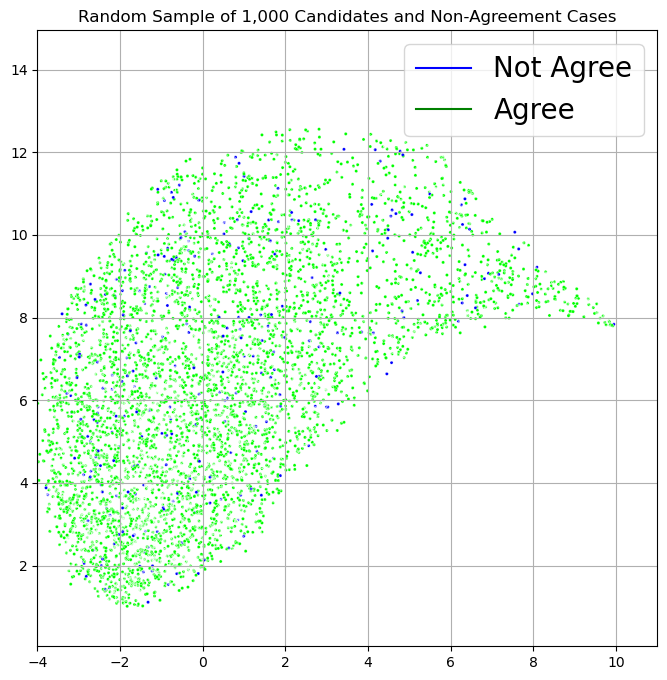

In [8]:
not_agree_1000 = np.asarray([36,67,68,75,84,93,105,111,112,117,131,136,141,145,149,150, \
             152,154,155,168,175,176,18,207,211,215,220,224,225,238,249,288,\
              292,298,302,303,307,317,318,330,338,374,393,419,425,443,454,\
              499,517,606,617,623,671,686,766,824,877,924,995])-1


import pandas as pd  
from sklearn import svm
from scipy.io import loadmat
from sklearn.svm import SVC
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import precision_recall_curve
from numpy import savetxt

import umap.umap_ as umap
import seaborn as sns
import random


from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import os, glob
from sklearn.metrics import silhouette_score
import numpy as np
from sklearn.preprocessing import normalize

def kl_divergence(p, q, eps=1e-10):
    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)
    return np.sum(p * np.log(p / q))


all_label = dict()
all_index= dict()
all_index_reverse= dict()
all_label_reverse= dict()


pt_ch_mapping ={
            # "EC130_513": [3],
            "EC130_200": [1,13],
            # "EC131_513": [273, 274, 275, 276, 282, 283, 284],
            # "EC131_513": [273, 275, 282, 284],
            "EC133_200": [282, 291, 292, 293],
            # "EC135_200": [303, 304],
            "EC135_200": [303],
            # "EC137_200": [258, 260, 271, 272],
            "EC137_200": [257, 258, 259, 269],
            # "EC143_513": [327, 329, 336, 338, 339],
            # "EC143_200": [329, 336, 338, 339],
            "EC143_200": [339],
            # "EC157_513": [323, 331, 332],
            # "EC157_200": [321, 323, 331, 332],
            "EC157_200": [321, 332, 333, 334],
            # "EC162_200": [85, 86, 99, 100],
            "EC162_200": [85, 86],
            "EC175_200": [301, 302],
            "EC183_200": [290],
            "EC186_200": [299, 300, 301],
            # "EC187_200": [309, 310, 311],
            "EC187_200": [309, 310],
            # "EC191_513": [2, 3, 4, 11, 12, 13, 65],
            # "EC191_200": [11, 12, 65],
            "EC191_200": [2, 3, 4],
            "EC196_200": [300, 301, 303],
            # "EC219_513": [399, 400, 401, 402, 403],
            # "EC219_200": [399, 400, 401, 403],
            "EC219_200": [399, 400, 402, 403],
            "EC220_200": [53, 54, 76, 77],
            "EC221_200": [376, 377],
            # "EC222_513": [267,268,269,270,277],
            "EC222_200": [267, 268, 269, 270],
            }



all_specs_label = []
all_specs = np.empty((0, 60))
# all_specs = np.empty((0, 31293))
file_list = []
pathname = '/scratch/dazhang/MATLAB/'
for patient, channal_list in pt_ch_mapping.items():
    print(patient, channal_list)
    path = pathname + patient+'/'
    ls_specs = np.empty((0, 60))
    # ls_specs = np.empty((0, 31293))

    for cur_channel in channal_list:
        cur_channel = str(cur_channel) 
        cur_channel_list = []   
        for filename in glob.glob(os.path.join(path, '*.mat')):
            
                # each_file = 'ls_ripple_'+str(patient)+'_Channel_' + str(cur_channel) + '_binsize_10_Block_'+str(blk)+'.mat'
            if  ("ls_ripple" not in filename) or  ("binsize_1_" in filename):
                continue
            with open(os.path.join(os.getcwd(), filename), 'r') as f: 
                if "Channel_"+str(cur_channel)+"_" in filename and ("-empty" not in filename):
                    # print(filename)
                    specs = loadmat(filename)['ls_ripple']
                    file_list.append(filename)
                    # print(specs.shape)
                    cur_channel_list.append(specs.shape[0])
                    ls_specs = np.concatenate([ls_specs, specs], axis=0)

    all_specs_label = np.concatenate([all_specs_label, [patient]*len(ls_specs)])
    all_specs = np.concatenate([all_specs, ls_specs], axis=0)

print(all_specs.shape, all_specs_label.shape)

# exit(0)
test_shape2 = []
all_spikes_label = np.empty((0, 1))
manual_label_spikes = list()
for each_file in file_list:
    patient_name = each_file.split("/")[-2]
    actural_file = each_file.split("/")[-1]
    actural_file_list = actural_file.split("_")
    spike_file_name = pathname + patient_name+"/"+actural_file_list[0]+"_spikes_"+"_".join(actural_file_list[2:6])+"_1_"+"_".join(actural_file_list[7:])

    with open(spike_file_name, 'r') as f: 
        spikes = loadmat(spike_file_name)['ls_spikes']


    all_spikes_label = np.concatenate([all_spikes_label, spikes])

all_ripples = all_specs

print(all_ripples.shape)

all_vectors = np.asarray(all_ripples)


embedding = umap.UMAP(n_components=2, min_dist=0.2, metric='euclidean',n_neighbors=15,random_state=42, n_epochs=100, verbose=True).fit_transform(all_vectors)

#Import required module
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min
#Initialize the class object
#930 is good
kmeans = KMeans(n_clusters = 5,random_state = 920)

kmeans_label = kmeans.fit(embedding)
closest, all_points_w_labels = pairwise_distances_argmin_min(kmeans_label.cluster_centers_, embedding)

# print(closest)

actual_score = silhouette_score(embedding, all_spikes_label)



# red: spike
# blue: ripple
c_list = []
for i, txt in enumerate(all_spikes_label):
    spike = all_spikes_label[i]
    if (i not in combined_idx_1000) and (i not in combined_idx_4000):
        if spike == 0:
            # cc = [1, 1, 1]  # Whites
            cc = [0, 0, 0]   # Black
        else:
            cc = [1, 0, 0] 
            # cc = [0, 0, 0]
            # cc = [1, 1, 1]
        cc = [1, 1, 1, 0]
    else:
        if (i in combined_idx_4000[not_agree_4000]) or (i in combined_idx_1000[not_agree_1000]):
            # print(i)
            cc = [0, 0, 1, 1] 
        else:
            cc = [0, 1, 0, 1] 
    c_list.append(cc)



import matplotlib.lines as mlines

not_agree = mlines.Line2D([], [], color='blue', label='Not Agree')
agree = mlines.Line2D([], [], color='green', label='Agree')



fig, ax = plt.subplots(figsize=(8,8))
ax = sns.scatterplot(x=embedding[:,0], y=embedding[:,1], c=c_list, s=5)
ax.legend(handles=[not_agree, agree], fontsize=20, ncol=1)


ax.grid(True)
ax.axis('equal')

ax.set_xlim(-4, 11)
ax.set_ylim(0, 15)

ax.title.set_text("Random Sample of 1,000 Candidates and Non-Agreement Cases")
plt.show()
# plt.legend()
# plt.savefig("plot_prob_dots_true_200_only_spike.png")
# plt.savefig("plot_prob_dots_true_200.png")
plt.close()



EC130_200 [1, 13]
EC133_200 [282, 291, 292, 293]
EC135_200 [303]
EC137_200 [257, 258, 259, 269]
EC143_200 [339]
EC157_200 [321, 332, 333, 334]
EC162_200 [85, 86]
EC175_200 [301, 302]
EC183_200 [290]
EC186_200 [299, 300, 301]
EC187_200 [309, 310]
EC191_200 [2, 3, 4]
EC196_200 [300, 301, 303]
EC219_200 [399, 400, 402, 403]
EC220_200 [53, 54, 76, 77]
EC221_200 [376, 377]
EC222_200 [267, 268, 269, 270]
(31847, 60) (31847,)
(31847, 60)
UMAP(min_dist=0.2, n_epochs=100, n_jobs=1, random_state=42, verbose=True)
Tue Sep 15 04:53:51 2026 Construct fuzzy simplicial set
Tue Sep 15 04:53:51 2026 Finding Nearest Neighbors
Tue Sep 15 04:53:51 2026 Building RP forest with 14 trees


/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Tue Sep 15 04:53:51 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	Stopping threshold met -- exiting after 4 iterations
Tue Sep 15 04:53:53 2026 Finished Nearest Neighbor Search
Tue Sep 15 04:53:53 2026 Construct embedding


Epochs completed:   0%|            0/100 [00:00]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs
Tue Sep 15 04:53:58 2026 Finished embedding


/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


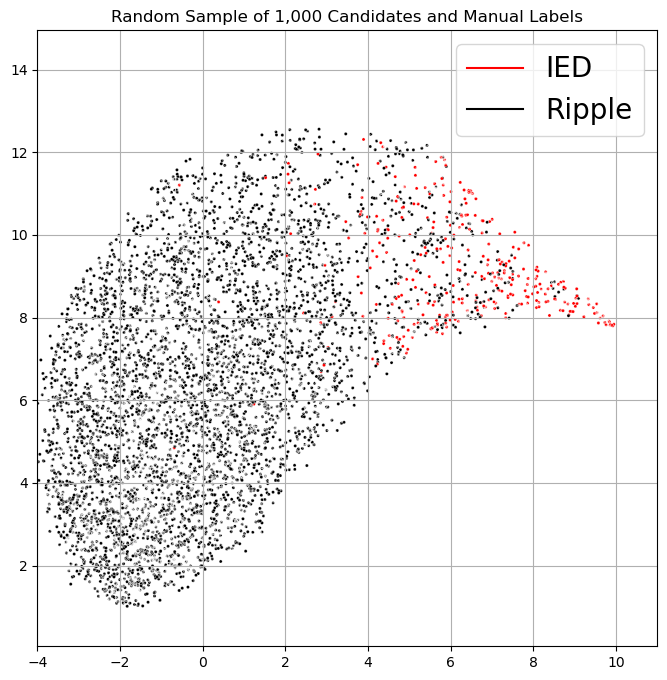

In [9]:
import pandas as pd  
from sklearn import svm
from scipy.io import loadmat
from sklearn.svm import SVC
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import precision_recall_curve
from numpy import savetxt

import umap.umap_ as umap
import seaborn as sns
import random


from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import os, glob
from sklearn.metrics import silhouette_score
import numpy as np
from sklearn.preprocessing import normalize

def kl_divergence(p, q, eps=1e-10):
    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)
    return np.sum(p * np.log(p / q))


all_label = dict()
all_index= dict()
all_index_reverse= dict()
all_label_reverse= dict()


pt_ch_mapping ={
            # "EC130_513": [3],
            "EC130_200": [1,13],
            # "EC131_513": [273, 274, 275, 276, 282, 283, 284],
            # "EC131_513": [273, 275, 282, 284],
            "EC133_200": [282, 291, 292, 293],
            # "EC135_200": [303, 304],
            "EC135_200": [303],
            # "EC137_200": [258, 260, 271, 272],
            "EC137_200": [257, 258, 259, 269],
            # "EC143_513": [327, 329, 336, 338, 339],
            # "EC143_200": [329, 336, 338, 339],
            "EC143_200": [339],
            # "EC157_513": [323, 331, 332],
            # "EC157_200": [321, 323, 331, 332],
            "EC157_200": [321, 332, 333, 334],
            # "EC162_200": [85, 86, 99, 100],
            "EC162_200": [85, 86],
            "EC175_200": [301, 302],
            "EC183_200": [290],
            "EC186_200": [299, 300, 301],
            # "EC187_200": [309, 310, 311],
            "EC187_200": [309, 310],
            # "EC191_513": [2, 3, 4, 11, 12, 13, 65],
            # "EC191_200": [11, 12, 65],
            "EC191_200": [2, 3, 4],
            "EC196_200": [300, 301, 303],
            # "EC219_513": [399, 400, 401, 402, 403],
            # "EC219_200": [399, 400, 401, 403],
            "EC219_200": [399, 400, 402, 403],
            "EC220_200": [53, 54, 76, 77],
            "EC221_200": [376, 377],
            # "EC222_513": [267,268,269,270,277],
            "EC222_200": [267, 268, 269, 270],
            }



all_specs_label = []
all_specs = np.empty((0, 60))
# all_specs = np.empty((0, 31293))
file_list = []
pathname = '/scratch/dazhang/MATLAB/'
for patient, channal_list in pt_ch_mapping.items():
    print(patient, channal_list)
    path = pathname + patient+'/'
    ls_specs = np.empty((0, 60))
    # ls_specs = np.empty((0, 31293))

    for cur_channel in channal_list:
        cur_channel = str(cur_channel) 
        cur_channel_list = []   
        for filename in glob.glob(os.path.join(path, '*.mat')):
            
                # each_file = 'ls_ripple_'+str(patient)+'_Channel_' + str(cur_channel) + '_binsize_10_Block_'+str(blk)+'.mat'
            if  ("ls_ripple" not in filename) or  ("binsize_1_" in filename):
                continue
            with open(os.path.join(os.getcwd(), filename), 'r') as f: 
                if "Channel_"+str(cur_channel)+"_" in filename and ("-empty" not in filename):
                    # print(filename)
                    specs = loadmat(filename)['ls_ripple']
                    file_list.append(filename)
                    # print(specs.shape)
                    cur_channel_list.append(specs.shape[0])
                    ls_specs = np.concatenate([ls_specs, specs], axis=0)

    all_specs_label = np.concatenate([all_specs_label, [patient]*len(ls_specs)])
    all_specs = np.concatenate([all_specs, ls_specs], axis=0)

print(all_specs.shape, all_specs_label.shape)

# exit(0)
test_shape2 = []
all_spikes_label = np.empty((0, 1))
manual_label_spikes = list()
for each_file in file_list:
    patient_name = each_file.split("/")[-2]
    actural_file = each_file.split("/")[-1]
    actural_file_list = actural_file.split("_")
    spike_file_name = pathname + patient_name+"/"+actural_file_list[0]+"_spikes_"+"_".join(actural_file_list[2:6])+"_1_"+"_".join(actural_file_list[7:])

    with open(spike_file_name, 'r') as f: 
        spikes = loadmat(spike_file_name)['ls_spikes']


    all_spikes_label = np.concatenate([all_spikes_label, spikes])

all_ripples = all_specs

print(all_ripples.shape)

all_vectors = np.asarray(all_ripples)


embedding = umap.UMAP(n_components=2, min_dist=0.2, metric='euclidean',n_neighbors=15,random_state=42, n_epochs=100, verbose=True).fit_transform(all_vectors)

#Import required module
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min
#Initialize the class object
#930 is good
kmeans = KMeans(n_clusters = 5,random_state = 920)

kmeans_label = kmeans.fit(embedding)
closest, all_points_w_labels = pairwise_distances_argmin_min(kmeans_label.cluster_centers_, embedding)

# print(closest)

actual_score = silhouette_score(embedding, all_spikes_label)



c_list = []
for i, txt in enumerate(all_spikes_label):
    spike = all_spikes_label[i]
    if (i not in combined_idx_1000) and (i not in combined_idx_4000):
        if spike == 0:
            # cc = [1, 1, 1]  # Whites
            cc = [0, 0, 0, 0]   # Black
        else:
            cc = [1, 0, 0, 0] 
    else:
        if spike==0:
            # print(i)
            cc = [0, 0, 0, 1] 
        else:
            cc = [1, 0, 0, 1] 
    c_list.append(cc)



import matplotlib.lines as mlines

not_agree = mlines.Line2D([], [], color='red', label='IED')
agree = mlines.Line2D([], [], color='black', label='Ripple')



fig, ax = plt.subplots(figsize=(8,8))
ax = sns.scatterplot(x=embedding[:,0], y=embedding[:,1], c=c_list, s=5)
ax.legend(handles=[not_agree, agree], fontsize=20, ncol=1)


ax.grid(True)
ax.axis('equal')

ax.set_xlim(-4, 11)
ax.set_ylim(0, 15)

ax.title.set_text("Random Sample of 1,000 Candidates and Manual Labels")
plt.show()
# plt.legend()
# plt.savefig("plot_prob_dots_true_200_only_spike.png")
plt.savefig("plot_prob_dots_true_200.png")
plt.close()


EC130_200 [1, 13]
EC133_200 [282, 291, 292, 293]
EC135_200 [303]
EC137_200 [257, 258, 259, 269]
EC143_200 [339]
EC157_200 [321, 332, 333, 334]
EC162_200 [85, 86]
EC175_200 [301, 302]
EC183_200 [290]
EC186_200 [299, 300, 301]
EC187_200 [309, 310]
EC191_200 [2, 3, 4]
EC196_200 [300, 301, 303]
EC219_200 [399, 400, 402, 403]
EC220_200 [53, 54, 76, 77]
EC221_200 [376, 377]
EC222_200 [267, 268, 269, 270]
(31847, 60) (31847,)
(31847, 60)
UMAP(min_dist=0.2, n_epochs=100, n_jobs=1, random_state=42, verbose=True)
Tue Sep 15 04:54:07 2026 Construct fuzzy simplicial set
Tue Sep 15 04:54:07 2026 Finding Nearest Neighbors
Tue Sep 15 04:54:07 2026 Building RP forest with 14 trees


/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Tue Sep 15 04:54:08 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	Stopping threshold met -- exiting after 4 iterations
Tue Sep 15 04:54:09 2026 Finished Nearest Neighbor Search
Tue Sep 15 04:54:09 2026 Construct embedding


Epochs completed:   0%|            0/100 [00:00]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs
Tue Sep 15 04:54:14 2026 Finished embedding
mapped min, and max:  0.0 0.5
0.5 0.0
-4.1483297 9.943624 0.8951096 12.604202 0.83090633
-4.1483297 9.943624 0.8951096 12.604202 1.2035052


/tmp/ipykernel_2055849/331446150.py:181: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plasma = plt.cm.get_cmap('plasma')


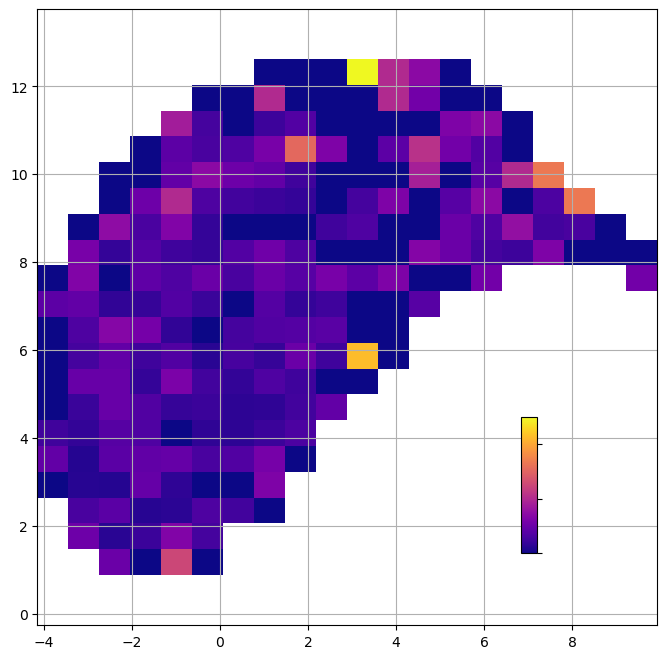

In [10]:

import pandas as pd  
from sklearn import svm
from scipy.io import loadmat
from sklearn.svm import SVC
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import precision_recall_curve
from numpy import savetxt

import umap.umap_ as umap
import seaborn as sns
import random
from collections import defaultdict


from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import os, glob
from sklearn.metrics import silhouette_score
import numpy as np
from sklearn.preprocessing import normalize

def kl_divergence(p, q, eps=1e-10):
    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)
    return np.sum(p * np.log(p / q))


all_label = dict()
all_index= dict()
all_index_reverse= dict()
all_label_reverse= dict()


pt_ch_mapping ={
            # "EC130_513": [3],
            "EC130_200": [1,13],
            # "EC131_513": [273, 274, 275, 276, 282, 283, 284],
            # "EC131_513": [273, 275, 282, 284],
            "EC133_200": [282, 291, 292, 293],
            # "EC135_200": [303, 304],
            "EC135_200": [303],
            # "EC137_200": [258, 260, 271, 272],
            "EC137_200": [257, 258, 259, 269],
            # "EC143_513": [327, 329, 336, 338, 339],
            # "EC143_200": [329, 336, 338, 339],
            "EC143_200": [339],
            # "EC157_513": [323, 331, 332],
            # "EC157_200": [321, 323, 331, 332],
            "EC157_200": [321, 332, 333, 334],
            # "EC162_200": [85, 86, 99, 100],
            "EC162_200": [85, 86],
            "EC175_200": [301, 302],
            "EC183_200": [290],
            "EC186_200": [299, 300, 301],
            # "EC187_200": [309, 310, 311],
            "EC187_200": [309, 310],
            # "EC191_513": [2, 3, 4, 11, 12, 13, 65],
            # "EC191_200": [11, 12, 65],
            "EC191_200": [2, 3, 4],
            "EC196_200": [300, 301, 303],
            # "EC219_513": [399, 400, 401, 402, 403],
            # "EC219_200": [399, 400, 401, 403],
            "EC219_200": [399, 400, 402, 403],
            "EC220_200": [53, 54, 76, 77],
            "EC221_200": [376, 377],
            # "EC222_513": [267,268,269,270,277],
            "EC222_200": [267, 268, 269, 270],
            }



all_specs_label = []
all_specs = np.empty((0, 60))
# all_specs = np.empty((0, 31293))
file_list = []
pathname = '/scratch/dazhang/MATLAB/'
for patient, channal_list in pt_ch_mapping.items():
    print(patient, channal_list)
    path = pathname + patient+'/'
    ls_specs = np.empty((0, 60))
    # ls_specs = np.empty((0, 31293))

    for cur_channel in channal_list:
        cur_channel = str(cur_channel) 
        cur_channel_list = []   
        for filename in glob.glob(os.path.join(path, '*.mat')):
            
                # each_file = 'ls_ripple_'+str(patient)+'_Channel_' + str(cur_channel) + '_binsize_10_Block_'+str(blk)+'.mat'
            if  ("ls_ripple" not in filename) or  ("binsize_1_" in filename):
                continue
            with open(os.path.join(os.getcwd(), filename), 'r') as f: 
                if "Channel_"+str(cur_channel)+"_" in filename and ("-empty" not in filename):
                    # print(filename)
                    specs = loadmat(filename)['ls_ripple']
                    file_list.append(filename)
                    # print(specs.shape)
                    cur_channel_list.append(specs.shape[0])
                    ls_specs = np.concatenate([ls_specs, specs], axis=0)

    all_specs_label = np.concatenate([all_specs_label, [patient]*len(ls_specs)])
    all_specs = np.concatenate([all_specs, ls_specs], axis=0)

print(all_specs.shape, all_specs_label.shape)

# exit(0)
test_shape2 = []
all_spikes_label = np.empty((0, 1))
manual_label_spikes = list()
for each_file in file_list:
    patient_name = each_file.split("/")[-2]
    actural_file = each_file.split("/")[-1]
    actural_file_list = actural_file.split("_")
    spike_file_name = pathname + patient_name+"/"+actural_file_list[0]+"_spikes_"+"_".join(actural_file_list[2:6])+"_1_"+"_".join(actural_file_list[7:])

    with open(spike_file_name, 'r') as f: 
        spikes = loadmat(spike_file_name)['ls_spikes']


    all_spikes_label = np.concatenate([all_spikes_label, spikes])

all_ripples = all_specs

print(all_ripples.shape)

all_vectors = np.asarray(all_ripples)


embedding = umap.UMAP(n_components=2, min_dist=0.2, metric='euclidean',n_neighbors=15,random_state=42, n_epochs=100, verbose=True).fit_transform(all_vectors)


min_vals = np.min(embedding, axis=0)
max_vals = np.max(embedding, axis=0)

grid_size = (20, 20)  # Number of divisions in x and y dimensions
x_bins = np.linspace(min_vals[0], max_vals[0], grid_size[0] + 1)
y_bins = np.linspace(min_vals[1], max_vals[1], grid_size[1] + 1)
ratio = (max_vals[1] - min_vals[1])/(max_vals[0] - min_vals[0])

grid_entropy = defaultdict()
grid_entropy_count = defaultdict()
grid_entropy_not_agree_count = defaultdict(int)
for i, (x, y) in enumerate(embedding):
    x_idx = np.searchsorted(x_bins, x) - 1
    y_idx = np.searchsorted(y_bins, y) - 1
    if 0 <= x_idx < grid_size[0] and 0 <= y_idx < grid_size[1] and ((i in combined_idx_1000) or (i in combined_idx_4000)):
        if (x_idx, y_idx) not in grid_entropy_count:
            grid_entropy_count[x_idx, y_idx] = 0
            grid_entropy_not_agree_count[x_idx, y_idx] = 0
        else:
            grid_entropy_count[x_idx, y_idx] += 1

for i, (x, y) in enumerate(embedding):
    x_idx = np.searchsorted(x_bins, x) - 1
    y_idx = np.searchsorted(y_bins, y) - 1
    if 0 <= x_idx < grid_size[0] and 0 <= y_idx < grid_size[1] and ((i in combined_idx_1000[not_agree_1000]) or (i in combined_idx_4000[not_agree_4000])):
        grid_entropy_not_agree_count[x_idx, y_idx] += 1



grid_entropy_value = np.zeros(grid_size)
while_x = grid_size[0]
while_y = grid_size[1]
mapped_min = float('inf')
mapped_max = -float('inf')

for i in range(while_x):
    for j in range(while_y):
        if (i, j) not in grid_entropy_count or (grid_entropy_count[i, j]==0):
            grid_entropy_value[i, j] = np.nan
        elif (i, j) in grid_entropy_count and (i, j) in grid_entropy_not_agree_count :
            # print(grid_entropy_not_agree_count[i, j] , grid_entropy_count[i, j])
            grid_entropy_value[i, j] = grid_entropy_not_agree_count[i, j] / grid_entropy_count[i, j]
            mapped_min = min(mapped_min, grid_entropy_value[i, j])
            mapped_max = max(mapped_max, grid_entropy_value[i, j])

print("mapped min, and max: ",mapped_min, mapped_max)

plasma = plt.cm.get_cmap('plasma')
fig, ax = plt.subplots(figsize=(8, 8))
ax.grid(True)
ax.axis('equal')
ax.set_facecolor('white')
cmap = plt.cm.plasma.copy()  # Copy the colormap to modify it
cmap.set_bad(color='white')  # Set masked values (0.0) to white

# Mask NaN values in the data to enforce white background
# masked_data = np.ma.masked_where(grid_entropy_value.T == 0.0, grid_entropy_value.T)
masked_data = np.ma.masked_invalid(grid_entropy_value.T)

print(np.max(masked_data), np.min(masked_data))
print(min_vals[0], max_vals[0], min_vals[1], max_vals[1], ratio)
ratio = (min_vals[0] - max_vals[0])/(min_vals[1]- max_vals[1])
print(min_vals[0], max_vals[0], min_vals[1], max_vals[1], ratio)

c2 = ax.imshow(masked_data, origin='lower', cmap=plasma, extent=[min_vals[0], max_vals[0], min_vals[1], max_vals[1]])

norm = plt.Normalize(mapped_min, mapped_max)
sm = plt.cm.ScalarMappable(cmap='plasma', norm=norm)
sm.set_array([]) 
cax = fig.add_axes([0.73, 0.20, 0.02, 0.17])
cbar = plt.colorbar(sm, cax = cax, orientation='vertical')
cbar.ax.set_yticklabels([]) 
plt.show()



In [11]:
from scipy.io import loadmat
import numpy as np
label_Da = loadmat('labels_final_Da_50.mat')['labels_all']
label_Jon = loadmat('labels_final_Jon_50.mat')['labels_all']
labels_Jon = [x.item() for x in label_Jon.flatten()]
labels_Da = [x.item() for x in label_Da.flatten()]
both_ripple = (np.array(labels_Jon) == "Ripple") & (np.array(labels_Da) == "Ripple")
ripple_idx_both_50 = np.where(both_ripple)[0]
first_pos = np.where(ripple_idx_both_50 > 1000)[0][0]
print(first_pos)
print(ripple_idx_both_50)

779
[   0    1    3 ... 4997 4998 4999]


In [12]:
# from scipy.io import loadmat
# import numpy as np
# label_Da = loadmat('labels_final_Da_20.mat')['labels_all']
# label_Jon = loadmat('labels_final_Jon_20.mat')['labels_all']
# labels_Jon = [x.item() for x in label_Jon.flatten()]
# labels_Da = [x.item() for x in label_Da.flatten()]
# both_ripple = (np.array(labels_Jon) == "Ripple") & (np.array(labels_Da) == "Ripple")
# ripple_idx_both_20 = np.where(both_ripple)[0]
# len(ripple_idx_both_20)

In [13]:
# import pandas as pd
# from sklearn import svm
# from scipy.io import loadmat
# from sklearn.svm import SVC
# import numpy as np
# from sklearn.manifold import TSNE
# import matplotlib.pyplot as plt
# from sklearn.model_selection import LeaveOneOut
# from sklearn.metrics import precision_recall_curve, silhouette_score
# from numpy import savetxt
# import umap.umap_ as umap
# import seaborn as sns
# import random
# from collections import defaultdict
# from sklearn.datasets import fetch_openml
# from sklearn.preprocessing import normalize
# import os, glob

# def kl_divergence(p, q, eps=1e-10):
#     p = np.clip(p, eps, 1)
#     q = np.clip(q, eps, 1)
#     return np.sum(p * np.log(p / q))

# all_label = {}
# all_index = {}
# all_index_reverse = {}
# all_label_reverse = {}

# pt_ch_mapping = {
#     "EC130_200": [1, 13],
#     "EC133_200": [282, 291, 292, 293],
#     "EC135_200": [303],
#     "EC137_200": [257, 258, 259, 269],
#     "EC143_200": [339],
#     "EC157_200": [321, 332, 333, 334],
#     "EC162_200": [85, 86],
#     "EC175_200": [301, 302],
#     "EC183_200": [290],
#     "EC186_200": [299, 300, 301],
#     "EC187_200": [309, 310],
#     "EC191_200": [2, 3, 4],
#     "EC196_200": [300, 301, 303],
#     "EC219_200": [399, 400, 402, 403],
#     "EC220_200": [53, 54, 76, 77],
#     "EC221_200": [376, 377],
#     "EC222_200": [267, 268, 269, 270],
# }

# all_specs_label = []
# all_specs = np.empty((0, 60))
# file_list = []
# pathname = '/scratch/dazhang/MATLAB/'

# for patient, channel_list in pt_ch_mapping.items():
#     print(patient, channel_list)
#     path = pathname + patient + '/'
#     ls_specs = np.empty((0, 60))

#     for cur_channel in channel_list:
#         cur_channel = str(cur_channel)

#         for filename in sorted(glob.glob(os.path.join(path, '*.mat'))):
#             if ("ls_ripple" not in filename) or ("binsize_1_" in filename):
#                 continue

#             if "Channel_" + cur_channel + "_" in filename and "-empty" not in filename:
#                 specs = loadmat(filename)['ls_ripple']
#                 file_list.append(filename)
#                 ls_specs = np.concatenate([ls_specs, specs], axis=0)

#     all_specs_label = np.concatenate([all_specs_label, [patient] * len(ls_specs)])
#     all_specs = np.concatenate([all_specs, ls_specs], axis=0)

# print("all_specs:", all_specs.shape)
# print("all_specs_label:", all_specs_label.shape)

# all_spikes_label = np.empty((0, 1))

# for each_file in file_list:
#     patient_name = each_file.split("/")[-2]
#     actual_file = each_file.split("/")[-1]
#     actual_file_list = actual_file.split("_")

#     spike_file_name = (pathname + patient_name + "/"
#         + actual_file_list[0] + "_spikes_"
#         + "_".join(actual_file_list[2:6])
#         + "_1_"
#         + "_".join(actual_file_list[7:]))

#     spikes = loadmat(spike_file_name)['ls_spikes']
#     all_spikes_label = np.concatenate([all_spikes_label, spikes])

# all_vectors = np.asarray(all_specs)

# print("all_vectors:", all_vectors.shape)

# embedding = umap.UMAP(
#     n_components=2,
#     min_dist=0.2,
#     metric='euclidean',
#     n_neighbors=15,
#     random_state=42,
#     n_epochs=100,
#     verbose=True
# ).fit_transform(all_vectors)

# print("embedding:", embedding.shape)

# min_vals = np.min(embedding, axis=0)
# max_vals = np.max(embedding, axis=0)


# grid_size = (20, 20)
# x_bins = np.linspace(min_vals[0], max_vals[0], grid_size[0] + 1)
# y_bins = np.linspace(min_vals[1], max_vals[1], grid_size[1] + 1)


# ratio = ((max_vals[1] - min_vals[1]) / (max_vals[0] - min_vals[0]))

# combined_idx_1000 = np.asarray(combined_idx_1000, dtype=int)
# combined_idx_4000 = np.asarray(combined_idx_4000, dtype=int)
# ripple_idx_both_50 = np.asarray(ripple_idx_both_50, dtype=int)

# all_selected_idx = set(
#     np.concatenate([
#         combined_idx_1000,
#         combined_idx_4000
#     ]).astype(int)
# )

# both_idx_1000 = combined_idx_1000[
#     ripple_idx_both_50[:778]
# ]

# both_idx_4000 = combined_idx_4000[
#     ripple_idx_both_50[778:] - 1000
# ]

# both_idx = set(
#     np.concatenate([
#         both_idx_1000,
#         both_idx_4000
#     ]).astype(int)
# )

# print("all selected:", len(all_selected_idx))
# print("both events:", len(both_idx))

# grid_total_count = defaultdict(int)
# grid_both_count = defaultdict(int)

# for i, (x, y) in enumerate(embedding):
#     x_idx = np.searchsorted(x_bins, x) - 1
#     y_idx = np.searchsorted(y_bins, y) - 1

#     # x_idx = min(x_idx, grid_size[0] - 1)
#     # y_idx = min(y_idx, grid_size[1] - 1)

#     if (0 <= x_idx < grid_size[0] and 0 <= y_idx < grid_size[1] and i in all_selected_idx):
#         grid_total_count[(x_idx, y_idx)] += 1

# for i, (x, y) in enumerate(embedding):
#     x_idx = np.searchsorted(x_bins, x) - 1
#     y_idx = np.searchsorted(y_bins, y) - 1

#     # x_idx = min(x_idx, grid_size[0] - 1)
#     # y_idx = min(y_idx, grid_size[1] - 1)

#     if (0 <= x_idx < grid_size[0] and 0 <= y_idx < grid_size[1]and i in both_idx):
#         grid_both_count[(x_idx, y_idx)] += 1

# grid_ratio_value = np.full(grid_size, np.nan)

# for i in range(grid_size[0]):
#     for j in range(grid_size[1]):
#         total = grid_total_count[(i, j)]

#         if total > 0:
#             both = grid_both_count[(i, j)]
#             grid_ratio_value[i, j] = both / total
#         elif total ==0:
#             grid_ratio_value[i, j] = 0

# valid_values = grid_ratio_value[~np.isnan(grid_ratio_value)]

# print("ratio range:", np.min(valid_values), np.max(valid_values))

# assert np.min(valid_values) >= 0
# assert np.max(valid_values) <= 1

# val_min = np.min(valid_values)
# val_max = np.max(valid_values)

# fig, ax = plt.subplots(figsize=(8, 8))
# ax.grid(True)
# ax.axis('equal')
# ax.set_facecolor('white')

# cmap = plt.cm.plasma.copy()
# cmap.set_bad(color='white')

# masked_data = np.ma.masked_invalid(grid_ratio_value.T)

# c2 = ax.imshow(
#     masked_data,
#     origin='lower',
#     cmap=cmap,
#     extent=[
#         min_vals[0],
#         max_vals[0],
#         min_vals[1],
#         max_vals[1]
#     ],
#     vmin=val_min,
#     vmax=val_max
# )

# cax = fig.add_axes([0.73, 0.20, 0.02, 0.17])

# cbar = plt.colorbar(c2, cax=cax, orientation='vertical')

# cbar.set_ticks([val_min, val_max])
# cbar.set_ticklabels([
#     f"{val_min:.3f}",
#     f"{val_max:.3f}"
# ])

# plt.show()

EC130_200 [1, 13]
EC133_200 [282, 291, 292, 293]
EC135_200 [303]
EC137_200 [257, 258, 259, 269]
EC143_200 [339]
EC157_200 [321, 332, 333, 334]
EC162_200 [85, 86]
EC175_200 [301, 302]
EC183_200 [290]
EC186_200 [299, 300, 301]
EC187_200 [309, 310]
EC191_200 [2, 3, 4]
EC196_200 [300, 301, 303]
EC219_200 [399, 400, 402, 403]
EC220_200 [53, 54, 76, 77]
EC221_200 [376, 377]
EC222_200 [267, 268, 269, 270]
(31847, 60) (31847,)
(31847, 60)
UMAP(min_dist=0.2, n_epochs=100, n_jobs=1, random_state=42, verbose=True)
Tue Sep 15 04:54:15 2026 Construct fuzzy simplicial set
Tue Sep 15 04:54:15 2026 Finding Nearest Neighbors
Tue Sep 15 04:54:15 2026 Building RP forest with 14 trees


/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Tue Sep 15 04:54:16 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	Stopping threshold met -- exiting after 4 iterations
Tue Sep 15 04:54:17 2026 Finished Nearest Neighbor Search
Tue Sep 15 04:54:17 2026 Construct embedding


Epochs completed:   0%|            0/100 [00:00]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs
Tue Sep 15 04:54:22 2026 Finished embedding
mapped min, and max:  0.0 1.0
1.0 0.0
-4.1483297 9.943624 0.8951096 12.604202 0.83090633
-4.1483297 9.943624 0.8951096 12.604202 1.2035052


/tmp/ipykernel_2055849/2907201923.py:184: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plasma = plt.cm.get_cmap('plasma')


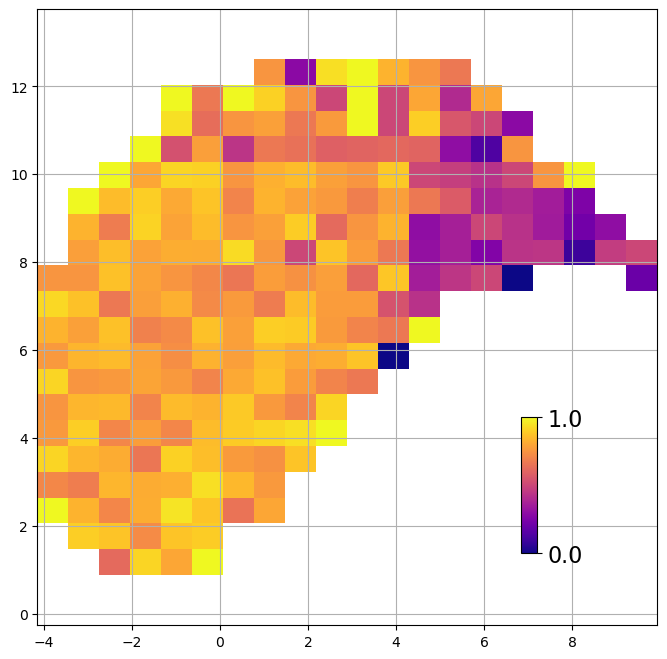

In [14]:
import pandas as pd  
from sklearn import svm
from scipy.io import loadmat
from sklearn.svm import SVC
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import precision_recall_curve
from numpy import savetxt

import umap.umap_ as umap
import seaborn as sns
import random
from collections import defaultdict


from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import os, glob
from sklearn.metrics import silhouette_score
import numpy as np
from sklearn.preprocessing import normalize

def kl_divergence(p, q, eps=1e-10):
    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)
    return np.sum(p * np.log(p / q))


all_label = dict()
all_index= dict()
all_index_reverse= dict()
all_label_reverse= dict()


pt_ch_mapping ={
            # "EC130_513": [3],
            "EC130_200": [1,13],
            # "EC131_513": [273, 274, 275, 276, 282, 283, 284],
            # "EC131_513": [273, 275, 282, 284],
            "EC133_200": [282, 291, 292, 293],
            # "EC135_200": [303, 304],
            "EC135_200": [303],
            # "EC137_200": [258, 260, 271, 272],
            "EC137_200": [257, 258, 259, 269],
            # "EC143_513": [327, 329, 336, 338, 339],
            # "EC143_200": [329, 336, 338, 339],
            "EC143_200": [339],
            # "EC157_513": [323, 331, 332],
            # "EC157_200": [321, 323, 331, 332],
            "EC157_200": [321, 332, 333, 334],
            # "EC162_200": [85, 86, 99, 100],
            "EC162_200": [85, 86],
            "EC175_200": [301, 302],
            "EC183_200": [290],
            "EC186_200": [299, 300, 301],
            # "EC187_200": [309, 310, 311],
            "EC187_200": [309, 310],
            # "EC191_513": [2, 3, 4, 11, 12, 13, 65],
            # "EC191_200": [11, 12, 65],
            "EC191_200": [2, 3, 4],
            "EC196_200": [300, 301, 303],
            # "EC219_513": [399, 400, 401, 402, 403],
            # "EC219_200": [399, 400, 401, 403],
            "EC219_200": [399, 400, 402, 403],
            "EC220_200": [53, 54, 76, 77],
            "EC221_200": [376, 377],
            # "EC222_513": [267,268,269,270,277],
            "EC222_200": [267, 268, 269, 270],
            }



all_specs_label = []
all_specs = np.empty((0, 60))
# all_specs = np.empty((0, 31293))
file_list = []
pathname = '/scratch/dazhang/MATLAB/'
for patient, channal_list in pt_ch_mapping.items():
    print(patient, channal_list)
    path = pathname + patient+'/'
    ls_specs = np.empty((0, 60))
    # ls_specs = np.empty((0, 31293))

    for cur_channel in channal_list:
        cur_channel = str(cur_channel) 
        cur_channel_list = []   
        for filename in glob.glob(os.path.join(path, '*.mat')):
            
                # each_file = 'ls_ripple_'+str(patient)+'_Channel_' + str(cur_channel) + '_binsize_10_Block_'+str(blk)+'.mat'
            if  ("ls_ripple" not in filename) or  ("binsize_1_" in filename):
                continue
            with open(os.path.join(os.getcwd(), filename), 'r') as f: 
                if "Channel_"+str(cur_channel)+"_" in filename and ("-empty" not in filename):
                    # print(filename)
                    specs = loadmat(filename)['ls_ripple']
                    file_list.append(filename)
                    # print(specs.shape)
                    cur_channel_list.append(specs.shape[0])
                    ls_specs = np.concatenate([ls_specs, specs], axis=0)

    all_specs_label = np.concatenate([all_specs_label, [patient]*len(ls_specs)])
    all_specs = np.concatenate([all_specs, ls_specs], axis=0)

print(all_specs.shape, all_specs_label.shape)

# exit(0)
test_shape2 = []
all_spikes_label = np.empty((0, 1))
manual_label_spikes = list()
for each_file in file_list:
    patient_name = each_file.split("/")[-2]
    actural_file = each_file.split("/")[-1]
    actural_file_list = actural_file.split("_")
    spike_file_name = pathname + patient_name+"/"+actural_file_list[0]+"_spikes_"+"_".join(actural_file_list[2:6])+"_1_"+"_".join(actural_file_list[7:])

    with open(spike_file_name, 'r') as f: 
        spikes = loadmat(spike_file_name)['ls_spikes']


    all_spikes_label = np.concatenate([all_spikes_label, spikes])

all_ripples = all_specs

print(all_ripples.shape)

all_vectors = np.asarray(all_ripples)


embedding = umap.UMAP(n_components=2, min_dist=0.2, metric='euclidean',n_neighbors=15,random_state=42, n_epochs=100, verbose=True).fit_transform(all_vectors)


min_vals = np.min(embedding, axis=0)
max_vals = np.max(embedding, axis=0)

grid_size = (20, 20)  # Number of divisions in x and y dimensions
x_bins = np.linspace(min_vals[0], max_vals[0], grid_size[0] + 1)
y_bins = np.linspace(min_vals[1], max_vals[1], grid_size[1] + 1)
ratio = (max_vals[1] - min_vals[1])/(max_vals[0] - min_vals[0])

grid_entropy = defaultdict()
grid_entropy_count = defaultdict()
grid_entropy_not_agree_count = defaultdict(int)
for i, (x, y) in enumerate(embedding):
    x_idx = np.searchsorted(x_bins, x) - 1
    y_idx = np.searchsorted(y_bins, y) - 1
    if 0 <= x_idx < grid_size[0] and 0 <= y_idx < grid_size[1] and ((i in combined_idx_1000) or (i in combined_idx_4000)):
        if (x_idx, y_idx) not in grid_entropy_count:
            grid_entropy_count[x_idx, y_idx] = 0
            grid_entropy_not_agree_count[x_idx, y_idx] = 0
        # else:
        grid_entropy_count[x_idx, y_idx] += 1

for i, (x, y) in enumerate(embedding):
    x_idx = np.searchsorted(x_bins, x) - 1
    y_idx = np.searchsorted(y_bins, y) - 1

    # x_idx = min(x_idx, grid_size[0] - 1)
    # y_idx = min(y_idx, grid_size[1] - 1)   
    if 0 <= x_idx < grid_size[0] and 0 <= y_idx < grid_size[1] and ((i in combined_idx_1000[ripple_idx_both_50[:778]]) or (i in combined_idx_4000[ripple_idx_both_50[778:]-1000])):
        grid_entropy_not_agree_count[x_idx, y_idx] += 1



grid_entropy_value = np.zeros(grid_size)
while_x = grid_size[0]
while_y = grid_size[1]
val_min = float('inf')
val_max = -float('inf')

for i in range(while_x):
    for j in range(while_y):
        if (i, j) not in grid_entropy_count or (grid_entropy_count[i, j]==0):
            grid_entropy_value[i, j] = np.nan
        elif (i, j) in grid_entropy_count and (i, j) in grid_entropy_not_agree_count :
            # print(grid_entropy_not_agree_count[i, j] , grid_entropy_count[i, j])
            grid_entropy_value[i, j] = grid_entropy_not_agree_count[i, j] / grid_entropy_count[i, j]
            val_min = min(val_min, grid_entropy_value[i, j])
            val_max = max(val_max, grid_entropy_value[i, j])

print("mapped min, and max: ",val_min, val_max)

plasma = plt.cm.get_cmap('plasma')
fig, ax = plt.subplots(figsize=(8, 8))
ax.grid(True)
ax.axis('equal')
ax.set_facecolor('white')
cmap = plt.cm.plasma.copy()  # Copy the colormap to modify it
cmap.set_bad(color='white')  # Set masked values (0.0) to white

# Mask NaN values in the data to enforce white background
# masked_data = np.ma.masked_where(grid_entropy_value.T == 0.0, grid_entropy_value.T)
masked_data = np.ma.masked_invalid(grid_entropy_value.T)

print(np.max(masked_data), np.min(masked_data))
print(min_vals[0], max_vals[0], min_vals[1], max_vals[1], ratio)
ratio = (min_vals[0] - max_vals[0])/(min_vals[1]- max_vals[1])
print(min_vals[0], max_vals[0], min_vals[1], max_vals[1], ratio)

c2 = ax.imshow(masked_data, origin='lower', cmap=plasma, extent=[min_vals[0], max_vals[0], min_vals[1], max_vals[1]])

# norm = plt.Normalize(mapped_min, mapped_max)
# sm = plt.cm.ScalarMappable(cmap='plasma', norm=norm)
# sm.set_array([]) 
c2.set_clim(val_min, val_max)
cax = fig.add_axes([0.73, 0.20, 0.02, 0.17])
cbar = plt.colorbar(c2, cax = cax, orientation='vertical')
cbar.set_ticks([val_min, val_max])
cbar.ax.tick_params(labelsize=16)
cbar.set_ticklabels([str(val_min), str(val_max)])
plt.show()

In [15]:
from scipy.io import loadmat
import numpy as np
label_Da = loadmat('labels_final_Da_50.mat')['labels_all']
label_Jon = loadmat('labels_final_Jon_50.mat')['labels_all']
labels_Jon = [x.item() for x in label_Jon.flatten()]
labels_Da = [x.item() for x in label_Da.flatten()]
both_IED = (np.array(labels_Jon) == "IED") & (np.array(labels_Da) == "IED")
IED_idx_both_50 = np.where(both_IED)[0]
first_pos = np.where(IED_idx_both_50 >= 1000)[0][0]
print(first_pos)
print(len(ripple_idx_both_50))

140
3734


EC130_200 [1, 13]
EC133_200 [282, 291, 292, 293]
EC135_200 [303]
EC137_200 [257, 258, 259, 269]
EC143_200 [339]
EC157_200 [321, 332, 333, 334]
EC162_200 [85, 86]
EC175_200 [301, 302]
EC183_200 [290]
EC186_200 [299, 300, 301]
EC187_200 [309, 310]
EC191_200 [2, 3, 4]
EC196_200 [300, 301, 303]
EC219_200 [399, 400, 402, 403]
EC220_200 [53, 54, 76, 77]
EC221_200 [376, 377]
EC222_200 [267, 268, 269, 270]
(31847, 60) (31847,)
(31847, 60)
UMAP(min_dist=0.2, n_epochs=100, n_jobs=1, random_state=42, verbose=True)
Tue Sep 15 04:54:23 2026 Construct fuzzy simplicial set
Tue Sep 15 04:54:23 2026 Finding Nearest Neighbors
Tue Sep 15 04:54:23 2026 Building RP forest with 14 trees


/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Tue Sep 15 04:54:24 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	Stopping threshold met -- exiting after 4 iterations
Tue Sep 15 04:54:25 2026 Finished Nearest Neighbor Search
Tue Sep 15 04:54:25 2026 Construct embedding


Epochs completed:   0%|            0/100 [00:00]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs
Tue Sep 15 04:54:30 2026 Finished embedding
mapped min, and max:  0.0 1.0


/tmp/ipykernel_2055849/66246934.py:181: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plasma = plt.cm.get_cmap('plasma')


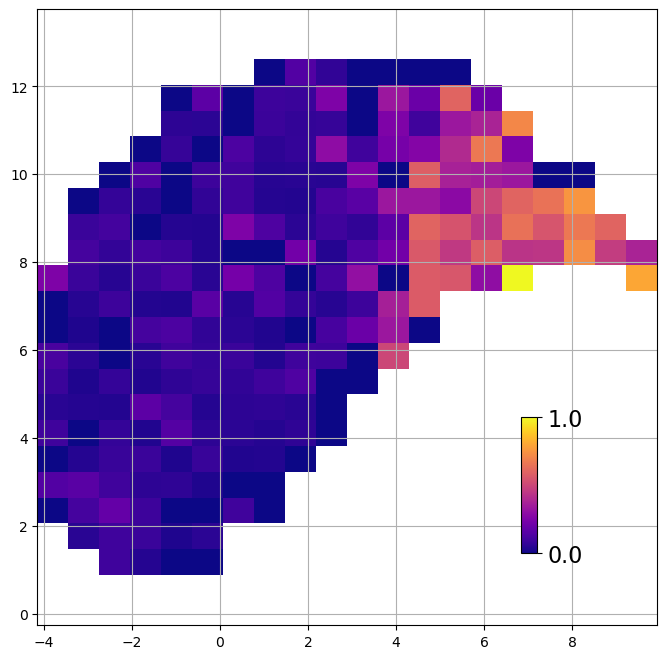

In [16]:
import pandas as pd  
from sklearn import svm
from scipy.io import loadmat
from sklearn.svm import SVC
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import precision_recall_curve
from numpy import savetxt

import umap.umap_ as umap
import seaborn as sns
import random
from collections import defaultdict


from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import os, glob
from sklearn.metrics import silhouette_score
import numpy as np
from sklearn.preprocessing import normalize

def kl_divergence(p, q, eps=1e-10):
    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)
    return np.sum(p * np.log(p / q))


all_label = dict()
all_index= dict()
all_index_reverse= dict()
all_label_reverse= dict()


pt_ch_mapping ={
            # "EC130_513": [3],
            "EC130_200": [1,13],
            # "EC131_513": [273, 274, 275, 276, 282, 283, 284],
            # "EC131_513": [273, 275, 282, 284],
            "EC133_200": [282, 291, 292, 293],
            # "EC135_200": [303, 304],
            "EC135_200": [303],
            # "EC137_200": [258, 260, 271, 272],
            "EC137_200": [257, 258, 259, 269],
            # "EC143_513": [327, 329, 336, 338, 339],
            # "EC143_200": [329, 336, 338, 339],
            "EC143_200": [339],
            # "EC157_513": [323, 331, 332],
            # "EC157_200": [321, 323, 331, 332],
            "EC157_200": [321, 332, 333, 334],
            # "EC162_200": [85, 86, 99, 100],
            "EC162_200": [85, 86],
            "EC175_200": [301, 302],
            "EC183_200": [290],
            "EC186_200": [299, 300, 301],
            # "EC187_200": [309, 310, 311],
            "EC187_200": [309, 310],
            # "EC191_513": [2, 3, 4, 11, 12, 13, 65],
            # "EC191_200": [11, 12, 65],
            "EC191_200": [2, 3, 4],
            "EC196_200": [300, 301, 303],
            # "EC219_513": [399, 400, 401, 402, 403],
            # "EC219_200": [399, 400, 401, 403],
            "EC219_200": [399, 400, 402, 403],
            "EC220_200": [53, 54, 76, 77],
            "EC221_200": [376, 377],
            # "EC222_513": [267,268,269,270,277],
            "EC222_200": [267, 268, 269, 270],
            }



all_specs_label = []
all_specs = np.empty((0, 60))
# all_specs = np.empty((0, 31293))
file_list = []
pathname = '/scratch/dazhang/MATLAB/'
for patient, channal_list in pt_ch_mapping.items():
    print(patient, channal_list)
    path = pathname + patient+'/'
    ls_specs = np.empty((0, 60))
    # ls_specs = np.empty((0, 31293))

    for cur_channel in channal_list:
        cur_channel = str(cur_channel) 
        cur_channel_list = []   
        for filename in glob.glob(os.path.join(path, '*.mat')):
            
                # each_file = 'ls_ripple_'+str(patient)+'_Channel_' + str(cur_channel) + '_binsize_10_Block_'+str(blk)+'.mat'
            if  ("ls_ripple" not in filename) or  ("binsize_1_" in filename):
                continue
            with open(os.path.join(os.getcwd(), filename), 'r') as f: 
                if "Channel_"+str(cur_channel)+"_" in filename and ("-empty" not in filename):
                    # print(filename)
                    specs = loadmat(filename)['ls_ripple']
                    file_list.append(filename)
                    # print(specs.shape)
                    cur_channel_list.append(specs.shape[0])
                    ls_specs = np.concatenate([ls_specs, specs], axis=0)

    all_specs_label = np.concatenate([all_specs_label, [patient]*len(ls_specs)])
    all_specs = np.concatenate([all_specs, ls_specs], axis=0)

print(all_specs.shape, all_specs_label.shape)

# exit(0)
test_shape2 = []
all_spikes_label = np.empty((0, 1))
manual_label_spikes = list()
for each_file in file_list:
    patient_name = each_file.split("/")[-2]
    actural_file = each_file.split("/")[-1]
    actural_file_list = actural_file.split("_")
    spike_file_name = pathname + patient_name+"/"+actural_file_list[0]+"_spikes_"+"_".join(actural_file_list[2:6])+"_1_"+"_".join(actural_file_list[7:])

    with open(spike_file_name, 'r') as f: 
        spikes = loadmat(spike_file_name)['ls_spikes']


    all_spikes_label = np.concatenate([all_spikes_label, spikes])

all_ripples = all_specs

print(all_ripples.shape)

all_vectors = np.asarray(all_ripples)


embedding = umap.UMAP(n_components=2, min_dist=0.2, metric='euclidean',n_neighbors=15,random_state=42, n_epochs=100, verbose=True).fit_transform(all_vectors)


min_vals = np.min(embedding, axis=0)
max_vals = np.max(embedding, axis=0)

grid_size = (20, 20)  # Number of divisions in x and y dimensions
x_bins = np.linspace(min_vals[0], max_vals[0], grid_size[0] + 1)
y_bins = np.linspace(min_vals[1], max_vals[1], grid_size[1] + 1)
ratio = (max_vals[1] - min_vals[1])/(max_vals[0] - min_vals[0])

grid_entropy = defaultdict()
grid_entropy_count = defaultdict()
grid_entropy_not_agree_count = defaultdict(int)
for i, (x, y) in enumerate(embedding):
    x_idx = np.searchsorted(x_bins, x) - 1
    y_idx = np.searchsorted(y_bins, y) - 1
    if 0 <= x_idx < grid_size[0] and 0 <= y_idx < grid_size[1] and ((i in combined_idx_1000) or (i in combined_idx_4000)):
        if (x_idx, y_idx) not in grid_entropy_count:
            grid_entropy_count[x_idx, y_idx] = 0
            grid_entropy_not_agree_count[x_idx, y_idx] = 0
        # else:
        grid_entropy_count[x_idx, y_idx] += 1

for i, (x, y) in enumerate(embedding):
    x_idx = np.searchsorted(x_bins, x) - 1
    y_idx = np.searchsorted(y_bins, y) - 1
    if 0 <= x_idx < grid_size[0] and 0 <= y_idx < grid_size[1] and ((i in combined_idx_1000[IED_idx_both_50[:140]]) or (i in combined_idx_4000[IED_idx_both_50[140:]-1000])):
        grid_entropy_not_agree_count[x_idx, y_idx] += 1



grid_entropy_value = np.zeros(grid_size)
while_x = grid_size[0]
while_y = grid_size[1]
val_min = float('inf')
val_max = -float('inf')

for i in range(while_x):
    for j in range(while_y):
        if (i, j) not in grid_entropy_count or (grid_entropy_count[i, j]==0):
            grid_entropy_value[i, j] = np.nan
        elif (i, j) in grid_entropy_count and (i, j) in grid_entropy_not_agree_count :
            # print(grid_entropy_not_agree_count[i, j] , grid_entropy_count[i, j])
            grid_entropy_value[i, j] = grid_entropy_not_agree_count[i, j] / grid_entropy_count[i, j]
            val_min = min(val_min, grid_entropy_value[i, j])
            val_max = max(val_max, grid_entropy_value[i, j])

print("mapped min, and max: ",val_min, val_max)

plasma = plt.cm.get_cmap('plasma')
fig, ax = plt.subplots(figsize=(8, 8))
ax.grid(True)
ax.axis('equal')
ax.set_facecolor('white')
cmap = plt.cm.plasma.copy()  # Copy the colormap to modify it
cmap.set_bad(color='white')  # Set masked values (0.0) to white

# Mask NaN values in the data to enforce white background
# masked_data = np.ma.masked_where(grid_entropy_value.T == 0.0, grid_entropy_value.T)
masked_data = np.ma.masked_invalid(grid_entropy_value.T)

c2 = ax.imshow(masked_data, origin='lower', cmap=plasma, extent=[min_vals[0], max_vals[0], min_vals[1], max_vals[1]])

# norm = plt.Normalize(mapped_min, mapped_max)
# sm = plt.cm.ScalarMappable(cmap='plasma', norm=norm)
# sm.set_array([]) 
c2.set_clim(val_min, val_max)
cax = fig.add_axes([0.73, 0.20, 0.02, 0.17])
cbar = plt.colorbar(c2, cax = cax, orientation='vertical')
cbar.ax.tick_params(labelsize=16)
cbar.set_ticks([val_min, val_max])
cbar.set_ticklabels([str(val_min), str(val_max)])
plt.show()

In [17]:
from scipy.io import loadmat
import numpy as np
label_Da = loadmat('labels_final_Da_50.mat')['labels_all']
label_Jon = loadmat('labels_final_Jon_50.mat')['labels_all']
labels_Jon = [x.item() for x in label_Jon.flatten()]
labels_Da = [x.item() for x in label_Da.flatten()]
both_Neither = (np.array(labels_Jon) == "Neither") & (np.array(labels_Da) == "Neither")
Neither_idx_both_50 = np.where(both_Neither)[0]
first_pos = np.where(Neither_idx_both_50 >= 1000)[0][0]
print(first_pos)
print(len(Neither_idx_both_50))

78
469


EC130_200 [1, 13]
EC133_200 [282, 291, 292, 293]
EC135_200 [303]
EC137_200 [257, 258, 259, 269]
EC143_200 [339]
EC157_200 [321, 332, 333, 334]
EC162_200 [85, 86]
EC175_200 [301, 302]
EC183_200 [290]
EC186_200 [299, 300, 301]
EC187_200 [309, 310]
EC191_200 [2, 3, 4]
EC196_200 [300, 301, 303]
EC219_200 [399, 400, 402, 403]
EC220_200 [53, 54, 76, 77]
EC221_200 [376, 377]
EC222_200 [267, 268, 269, 270]
(31847, 60) (31847,)
(31847, 60)
UMAP(min_dist=0.2, n_epochs=100, n_jobs=1, random_state=42, verbose=True)
Tue Sep 15 04:54:31 2026 Construct fuzzy simplicial set
Tue Sep 15 04:54:31 2026 Finding Nearest Neighbors
Tue Sep 15 04:54:31 2026 Building RP forest with 14 trees


/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Tue Sep 15 04:54:32 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	Stopping threshold met -- exiting after 4 iterations
Tue Sep 15 04:54:33 2026 Finished Nearest Neighbor Search
Tue Sep 15 04:54:33 2026 Construct embedding


Epochs completed:   0%|            0/100 [00:00]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs
Tue Sep 15 04:54:38 2026 Finished embedding
mapped min, and max:  0.0 0.5714285714285714


/tmp/ipykernel_2055849/2003672805.py:181: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plasma = plt.cm.get_cmap('plasma')


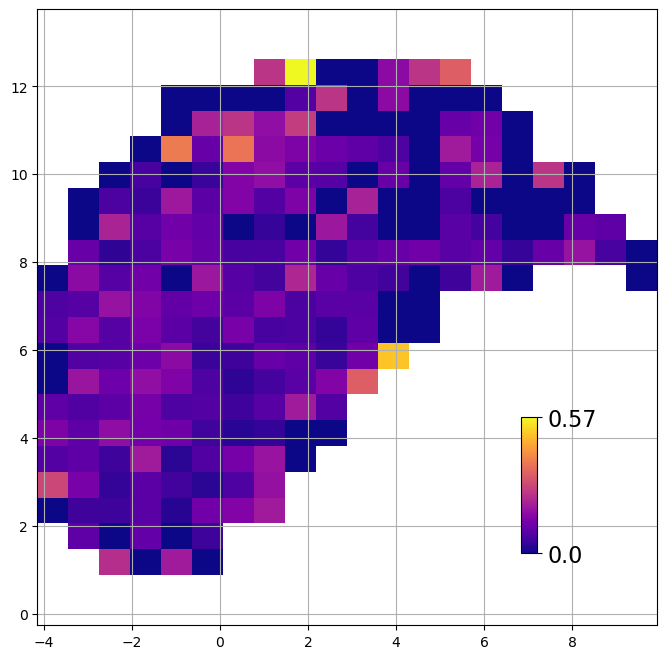

In [18]:
import pandas as pd  
from sklearn import svm
from scipy.io import loadmat
from sklearn.svm import SVC
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import precision_recall_curve
from numpy import savetxt

import umap.umap_ as umap
import seaborn as sns
import random
from collections import defaultdict


from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import os, glob
from sklearn.metrics import silhouette_score
import numpy as np
from sklearn.preprocessing import normalize

def kl_divergence(p, q, eps=1e-10):
    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)
    return np.sum(p * np.log(p / q))


all_label = dict()
all_index= dict()
all_index_reverse= dict()
all_label_reverse= dict()


pt_ch_mapping ={
            # "EC130_513": [3],
            "EC130_200": [1,13],
            # "EC131_513": [273, 274, 275, 276, 282, 283, 284],
            # "EC131_513": [273, 275, 282, 284],
            "EC133_200": [282, 291, 292, 293],
            # "EC135_200": [303, 304],
            "EC135_200": [303],
            # "EC137_200": [258, 260, 271, 272],
            "EC137_200": [257, 258, 259, 269],
            # "EC143_513": [327, 329, 336, 338, 339],
            # "EC143_200": [329, 336, 338, 339],
            "EC143_200": [339],
            # "EC157_513": [323, 331, 332],
            # "EC157_200": [321, 323, 331, 332],
            "EC157_200": [321, 332, 333, 334],
            # "EC162_200": [85, 86, 99, 100],
            "EC162_200": [85, 86],
            "EC175_200": [301, 302],
            "EC183_200": [290],
            "EC186_200": [299, 300, 301],
            # "EC187_200": [309, 310, 311],
            "EC187_200": [309, 310],
            # "EC191_513": [2, 3, 4, 11, 12, 13, 65],
            # "EC191_200": [11, 12, 65],
            "EC191_200": [2, 3, 4],
            "EC196_200": [300, 301, 303],
            # "EC219_513": [399, 400, 401, 402, 403],
            # "EC219_200": [399, 400, 401, 403],
            "EC219_200": [399, 400, 402, 403],
            "EC220_200": [53, 54, 76, 77],
            "EC221_200": [376, 377],
            # "EC222_513": [267,268,269,270,277],
            "EC222_200": [267, 268, 269, 270],
            }



all_specs_label = []
all_specs = np.empty((0, 60))
# all_specs = np.empty((0, 31293))
file_list = []
pathname = '/scratch/dazhang/MATLAB/'
for patient, channal_list in pt_ch_mapping.items():
    print(patient, channal_list)
    path = pathname + patient+'/'
    ls_specs = np.empty((0, 60))
    # ls_specs = np.empty((0, 31293))

    for cur_channel in channal_list:
        cur_channel = str(cur_channel) 
        cur_channel_list = []   
        for filename in glob.glob(os.path.join(path, '*.mat')):
            
                # each_file = 'ls_ripple_'+str(patient)+'_Channel_' + str(cur_channel) + '_binsize_10_Block_'+str(blk)+'.mat'
            if  ("ls_ripple" not in filename) or  ("binsize_1_" in filename):
                continue
            with open(os.path.join(os.getcwd(), filename), 'r') as f: 
                if "Channel_"+str(cur_channel)+"_" in filename and ("-empty" not in filename):
                    # print(filename)
                    specs = loadmat(filename)['ls_ripple']
                    file_list.append(filename)
                    # print(specs.shape)
                    cur_channel_list.append(specs.shape[0])
                    ls_specs = np.concatenate([ls_specs, specs], axis=0)

    all_specs_label = np.concatenate([all_specs_label, [patient]*len(ls_specs)])
    all_specs = np.concatenate([all_specs, ls_specs], axis=0)

print(all_specs.shape, all_specs_label.shape)

# exit(0)
test_shape2 = []
all_spikes_label = np.empty((0, 1))
manual_label_spikes = list()
for each_file in file_list:
    patient_name = each_file.split("/")[-2]
    actural_file = each_file.split("/")[-1]
    actural_file_list = actural_file.split("_")
    spike_file_name = pathname + patient_name+"/"+actural_file_list[0]+"_spikes_"+"_".join(actural_file_list[2:6])+"_1_"+"_".join(actural_file_list[7:])

    with open(spike_file_name, 'r') as f: 
        spikes = loadmat(spike_file_name)['ls_spikes']


    all_spikes_label = np.concatenate([all_spikes_label, spikes])

all_ripples = all_specs

print(all_ripples.shape)

all_vectors = np.asarray(all_ripples)


embedding = umap.UMAP(n_components=2, min_dist=0.2, metric='euclidean',n_neighbors=15,random_state=42, n_epochs=100, verbose=True).fit_transform(all_vectors)


min_vals = np.min(embedding, axis=0)
max_vals = np.max(embedding, axis=0)

grid_size = (20, 20)  # Number of divisions in x and y dimensions
x_bins = np.linspace(min_vals[0], max_vals[0], grid_size[0] + 1)
y_bins = np.linspace(min_vals[1], max_vals[1], grid_size[1] + 1)
ratio = (max_vals[1] - min_vals[1])/(max_vals[0] - min_vals[0])

grid_entropy = defaultdict()
grid_entropy_count = defaultdict()
grid_entropy_not_agree_count = defaultdict(int)
for i, (x, y) in enumerate(embedding):
    x_idx = np.searchsorted(x_bins, x) - 1
    y_idx = np.searchsorted(y_bins, y) - 1
    if 0 <= x_idx < grid_size[0] and 0 <= y_idx < grid_size[1] and ((i in combined_idx_1000) or (i in combined_idx_4000)):
        if (x_idx, y_idx) not in grid_entropy_count:
            grid_entropy_count[x_idx, y_idx] = 0
            grid_entropy_not_agree_count[x_idx, y_idx] = 0
        # else:
        grid_entropy_count[x_idx, y_idx] += 1

for i, (x, y) in enumerate(embedding):
    x_idx = np.searchsorted(x_bins, x) - 1
    y_idx = np.searchsorted(y_bins, y) - 1
    if 0 <= x_idx < grid_size[0] and 0 <= y_idx < grid_size[1] and ((i in combined_idx_1000[Neither_idx_both_50[:78]]) or (i in combined_idx_4000[Neither_idx_both_50[78:]-1000])):
        grid_entropy_not_agree_count[x_idx, y_idx] += 1



grid_entropy_value = np.zeros(grid_size)
while_x = grid_size[0]
while_y = grid_size[1]
val_min = float('inf')
val_max = -float('inf')

for i in range(while_x):
    for j in range(while_y):
        if (i, j) not in grid_entropy_count or (grid_entropy_count[i, j]==0):
            grid_entropy_value[i, j] = np.nan
        elif (i, j) in grid_entropy_count and (i, j) in grid_entropy_not_agree_count :
            # print(grid_entropy_not_agree_count[i, j] , grid_entropy_count[i, j])
            grid_entropy_value[i, j] = grid_entropy_not_agree_count[i, j] / grid_entropy_count[i, j]
            val_min = min(val_min, grid_entropy_value[i, j])
            val_max = max(val_max, grid_entropy_value[i, j])

print("mapped min, and max: ",val_min, val_max)

plasma = plt.cm.get_cmap('plasma')
fig, ax = plt.subplots(figsize=(8, 8))
ax.grid(True)
ax.axis('equal')
ax.set_facecolor('white')
cmap = plt.cm.plasma.copy()  # Copy the colormap to modify it
cmap.set_bad(color='white')  # Set masked values (0.0) to white

# Mask NaN values in the data to enforce white background
# masked_data = np.ma.masked_where(grid_entropy_value.T == 0.0, grid_entropy_value.T)
masked_data = np.ma.masked_invalid(grid_entropy_value.T)

# print(np.max(masked_data), np.min(masked_data))
# print(min_vals[0], max_vals[0], min_vals[1], max_vals[1], ratio)
# ratio = (min_vals[0] - max_vals[0])/(min_vals[1]- max_vals[1])
# print(min_vals[0], max_vals[0], min_vals[1], max_vals[1], ratio)

c2 = ax.imshow(masked_data, origin='lower', cmap=plasma, extent=[min_vals[0], max_vals[0], min_vals[1], max_vals[1]])

# norm = plt.Normalize(mapped_min, mapped_max)
# sm = plt.cm.ScalarMappable(cmap='plasma', norm=norm)
# sm.set_array([]) 
c2.set_clim(val_min, val_max)
cax = fig.add_axes([0.73, 0.20, 0.02, 0.17])
cbar = plt.colorbar(c2, cax = cax, orientation='vertical')
cbar.ax.tick_params(labelsize=16)
cbar.set_ticks([val_min, val_max])
cbar.set_ticklabels([f"{val_min:.1f}", f"{val_max:.2f}"])
plt.show()